# Notebook for experimenting with RDKit

In [2]:
import rdkit
from rdkit import Chem


## A simple ethanol molecule and inspecting its properties:

['__module__', '__doc__', '__reduce__', '__instance_size__', '__init__', '__copy__', '__deepcopy__', 'GetNumAtoms', 'GetNumHeavyAtoms', 'GetAtomWithIdx', 'GetNumBonds', 'GetBondWithIdx', 'GetNumConformers', 'AddConformer', 'GetConformer', 'GetConformers', 'RemoveAllConformers', 'RemoveConformer', 'GetBondBetweenAtoms', 'HasQuery', 'HasSubstructMatch', 'GetSubstructMatch', 'GetSubstructMatches', 'SetProp', 'SetDoubleProp', 'SetIntProp', 'SetUnsignedProp', 'SetBoolProp', 'HasProp', 'GetProp', 'GetDoubleProp', 'GetIntProp', 'GetUnsignedProp', 'GetBoolProp', 'ClearProp', 'ClearComputedProps', 'UpdatePropertyCache', 'NeedsUpdatePropertyCache', 'ClearPropertyCache', 'GetStereoGroups', 'GetPropNames', 'GetPropsAsDict', 'GetAromaticAtoms', 'GetAtomsMatchingQuery', '__safe_for_unpickling__', '__getstate_manages_dict__', '__getinitargs__', '__getstate__', '__setstate__', 'Debug', 'ToBinary', 'GetRingInfo', 'GetAtoms', 'GetBonds', '_repr_png_', '_repr_svg_', '_repr_html_', '__GetSubstructMatch', 

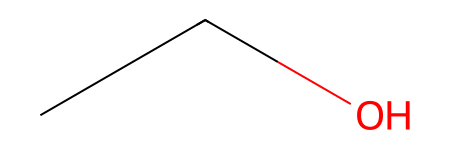

In [9]:
ethanol = Chem.MolFromSmiles('CCO')

print(ethanol.__dir__())

print("Atom count:", ethanol.GetNumAtoms())

ethanol_num_conformers = ethanol.GetNumConformers()

print(f"Number of conformers: {ethanol_num_conformers}")

print("Has 3D coordinates?",  ethanol_num_conformers> 0)

ethanol

In [ ]:
atom = ethanol.GetAtomWithIdx(0)
print("Atom element:", atom.GetSymbol())

ethanol_conformer = ethanol.GetConformer()
ethanol_conformer.GetAtomPosition(0)

## We get a Value Error here because there is no 3D spatial information in the molecule yet.

Atom element: C


ValueError: Bad Conformer Id

## Now giving the molecule a 3D structure

In [15]:
ethanol_3d = Chem.Mol(ethanol)
print("Atom count before adding H's:", ethanol_3d.GetNumAtoms())

# Explicitly add Hydrogens
ethanol_3d = Chem.AddHs(ethanol_3d)
print("Atom count after adding H's:", ethanol_3d.GetNumAtoms())

from rdkit.Chem import AllChem

# Embed molecule to get spatial information
AllChem.EmbedMolecule(ethanol_3d, randomSeed=42)

print("Has 3D coordinates now?", ethanol_3d.GetNumConformers() > 0)

# Extract and print the actual XYZ coordinates of the first atom
pos = ethanol_3d.GetConformer().GetAtomPosition(0)
print(f"Atom 0 ({ethanol_3d.GetAtomWithIdx(0).GetSymbol()}) 3D Position: X={pos.x:.3f}, Y={pos.y:.3f}, Z={pos.z:.3f}")

Atom count before adding H's: 3
Atom count after adding H's: 9
Has 3D coordinates now? True
Atom 0 (C) 3D Position: X=-0.953, Y=0.048, Z=0.042


## Visualizing the 3D molecule

In [22]:
import py3Dmol

def render_molecule_3d(mol):
# Convert RDKit molecule object to a string format py3Dmol understands
    block = Chem.MolToMolBlock(mol)

    # Create the interactive 3D viewer canvas
    viewer = py3Dmol.view(width=400, height=400)
    viewer.addModel(block, "molecule")

    # Style the visualization (stick representation shows bonds clearly)
    viewer.setStyle({'stick': {'radius': 0.12}, 'sphere': {'scale': 0.25}})

    return viewer

viewer = render_molecule_3d(ethanol_3d)
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Loading data from json file _(with scalability in mind)_

I have made use of ijson to load the targets one by one, such that if the json file was large, the loader would not run out of memory, instead of using the inbuilt json.loads() which would have loaded the entire file into memory. See [loader.py](loader.py)

Below, we are just embeding the molecule from its SMILES and rendering the 3D visualization for each target.
I foresee a future where we use a similar loop to map the features, align and score, where we would save best score to disk immediately.

In [ ]:
import loader

for target_id, target_data in loader.stream_targets():
    # Print structured textual metadata cleanly
    print("=" * 60)
    print(f"TARGET INITIALIZED : {target_id}")
    print("-" * 60)
    print(f"   Chemical Formula / SMILES Topology:")
    print(f"   {target_data['smiles']}")
    print("-" * 60)
    
    # Build the structural topology object via RDKit
    mol = Chem.MolFromSmiles(target_data['smiles'])
    mol_3d = Chem.AddHs(mol)  # Add hydrogens for accurate physical structures
    
    # Embed a trial 3D conformation so the viewer has rendering vectors
    AllChem.EmbedMolecule(mol_3d, randomSeed=42)
    
    # Trigger the interactive 3D rendering engine inline
    viewer = render_molecule_3d(mol_3d)
    viewer.show()


TARGET INITIALIZED : target_1
------------------------------------------------------------
   Chemical Formula / SMILES Topology:
   CC(C)Cc1ccc(cc1)C(C)C(O)=O
------------------------------------------------------------


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

TARGET INITIALIZED : target_2
------------------------------------------------------------
   Chemical Formula / SMILES Topology:
   CN1C=NC2=C1C(=O)N(C(=O)N2C)C
------------------------------------------------------------


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

TARGET INITIALIZED : target_3
------------------------------------------------------------
   Chemical Formula / SMILES Topology:
   CC(=O)Oc1ccccc1C(O)=O
------------------------------------------------------------


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

TARGET INITIALIZED : target_4
------------------------------------------------------------
   Chemical Formula / SMILES Topology:
   Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C
------------------------------------------------------------


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

TARGET INITIALIZED : target_5
------------------------------------------------------------
   Chemical Formula / SMILES Topology:
   COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4
------------------------------------------------------------


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Now for the task:

> Task:
>
> For each target, generate 3D conformers from the SMILES, align them to the pharmacophore
> interaction sites by matching ligand chemical features to the appropriate families, reject any pose
> with steric clashes against the excluded volumes, and select the single best surviving pose by score.
>
> The score for a pose is:
>
> `score = sum over all sites of: w_i * exp(-(d_i / 1.25)^2)`
>
> where `d_i` is the minimum distance from interaction site `i` to the nearest ligand atom whose chemical
> feature matches the site's family, and `w_i` is the site's weight.
>
> Your best conformer should achieve the highest possible score while avoiding all exclusion sphere
> clashes. For each target, the method must reach a percentage of the possible total score, rated by
> difficulty of the ligand molecule.

In [27]:
import os
from rdkit import RDConfig
from rdkit.Chem import ChemicalFeatures

# 1. Locate RDKit's built-in file containing standard pharma features
fdef_file = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')

# 2. Build the factory directly from RDKit's internal library
factory = ChemicalFeatures.BuildFeatureFactory(fdef_file)

target_id, target_data = next(loader.stream_targets())

factory.GetFeatureDefs()

{'Donor.SingleAtomDonor': '[$([N&!H0&v3,N&!H0&+1&v4,n&H1&+0,$([$([Nv3](-C)(-C)-C)]),$([$(n[n;H1]),$(nc[n;H1])])]),$([O,S;H1;+0])]',
 'Acceptor.SingleAtomAcceptor': '[$([O;H1;v2]),$([O;H0;v2;!$(O=N-*),$([O;-;!$(*-N=O)]),$([o;+0])]),$([n;+0;!X3;!$([n;H1](cc)cc),$([$([N;H0]#[C&v4])]),$([N&v3;H0;$(Nc)])]),$([F;$(F-[#6]);!$(FC[F,Cl,Br,I])])]',
 'NegIonizable.AcidicGroup': '[C,S](=[O,S,P])-[O;H1,H0&-1]',
 'PosIonizable.BasicGroup': '[$([$([N;H2&+0][$([C;!$(C=*)])])]),$([$([N;H1&+0]([$([C;!$(C=*)])])[$([C;!$(C=*)])])]),$([$([N;H0&+0]([$([C;!$(C=*)])])([$([C;!$(C=*)])])[$([C;!$(C=*)])])]);!$(N[a])]',
 'PosIonizable.PosN': '[#7;+;!$([N+]-[O-])]',
 'PosIonizable.Imidazole': 'c1ncnc1',
 'PosIonizable.Guanidine': 'NC(=N)N',
 'ZnBinder.ZnBinder1': '[S;D1]-[#6]',
 'ZnBinder.ZnBinder2': '[#6]-C(=O)-C-[S;D1]',
 'ZnBinder.ZnBinder3': '[#6]-C(=O)-C-C-[S;D1]',
 'ZnBinder.ZnBinder4': '[#6]-C(=O)-N-[O;D1]',
 'ZnBinder.ZnBinder5': '[#6]-C(=O)-[O;D1]',
 'ZnBinder.ZnBinder6': '[#6]-P(=O)(-O)-[C,O,N]-[C,H]',
 